In [ ]:
# Initialize Otter
import otter
grader = otter.Notebook("Econ126_Homework_03.ipynb")

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'

# Homework 3

**Instructions:** Complete the notebook below. Download the completed notebook in HTML format. Upload assignment using Canvas.

## Exercise: Income and Growth Across Countries

The data file `cross_country_gdp_per_capita.csv` contains annual data on GDP per capita for over 100 countries and is available here: https://raw.githubusercontent.com/letsgoexploring/economic-data/master/cross-country-production/csv/cross_country_gdp_per_capita.csv. The data are was constructed from the Penn World Table (https://www.rug.nl/ggdc/productivity/pwt/).

In this exercise, you will:

1. Analyze some basic facts about GDP per capita across the world.
2. Compute the average annual growth rate of GDP per capita for each country in the data.
3. Compute a linear regression of average GDP per capita growth on GDP per capita in the initial year.

Follow the instructions in the following cells.

### Part (a)

In [2]:
# Create a variable called `data` that stores the data in the file 'cross_country_gdp_per_capita.csv' in a DataFrame
# Make sure that 'Year', the left-most column of the data, is set to be the index column
# BEGIN SOLUTION
data = pd.read_csv('https://raw.githubusercontent.com/letsgoexploring/economic-data/master/cross-country-production/csv/cross_country_gdp_per_capita.csv',index_col=0,parse_dates = True)
# END SOLUTION

# Display the first 5 rows of data
# BEGIN SOLUTION
display(data.head())
# END SOLUTION

,Algeria - DZA,Argentina - ARG,Australia - AUS,Austria - AUT,Bangladesh - BGD,Barbados - BRB,Belgium - BEL,Benin - BEN,Bolivia (Plurinational State of) - BOL,Botswana - BWA,...,Tunisia - TUN,Turkey - TUR,U.R. of Tanzania: Mainland - TZA,Uganda - UGA,United Kingdom - GBR,United States - USA,Uruguay - URY,Venezuela (Bolivarian Republic of) - VEN,Zambia - ZMB,Zimbabwe - ZWE
year,,,,,,,,,,,,,,,,,,,,,
1960-01-01,10509.008358,3163.732710,15646.139353,10123.029724,1614.258962,8077.843086,10413.567949,1613.682642,1793.725019,501.963539,...,1672.383999,5105.784826,1124.951944,860.620171,12569.280813,19180.187484,7424.589274,6881.015186,1757.650342,2414.726327
1961-01-01,8734.654889,3225.229409,15666.440016,10675.157983,1594.635939,8591.699053,10966.940259,1620.385825,1806.270764,542.991691,...,1715.566809,5062.252401,1133.652078,860.173890,12817.946324,19342.103029,7495.573036,6781.865640,1785.884491,2480.505976
1962-01-01,4595.165489,3247.774783,16218.777695,11039.562197,1679.000245,9219.070754,11832.121657,1551.691450,1812.806730,596.211469,...,1733.662454,5257.709264,1212.530695,858.673399,12946.663809,20213.129847,7569.820959,6824.167909,1770.477253,2387.665504
1963-01-01,5320.490300,3084.691110,17097.551206,11412.303692,1736.151714,9026.570727,12284.827489,1601.555862,1906.996349,616.322979,...,1874.419709,5619.228307,1270.920176,848.627413,13379.151279,20788.538117,7316.025332,7192.137422,1824.180363,2363.511866
1964-01-01,5413.859929,3176.120812,17574.573982,11866.055096,1682.423109,8914.135597,13017.674457,1651.505927,1970.671432,646.745990,...,1886.067528,5655.940421,1429.397151,889.057113,14067.603724,21691.511003,7491.037965,7710.422273,2015.107433,2226.032210


In [3]:
# Each column contains data for a specific country. Create a variable called `n_countries` that is equal to the
#    length of `data.columns`
# BEGIN SOLUTION
n_countries = len(data.columns)

# Print the value of `n_countries`
# BEGIN SOLUTION
print("Number of countries: ",n_countries)
# END SOLUTION

Number of countries:  104


In [4]:
# Each column contains data for a specific year. Create a variable called `n_years` that is equal to the
#    length of `data.index`
# BEGIN SOLUTION
n_years = len(data.index)
# END SOLUTION

# BEGIN SOLUTION
print("Number of years of observations: ",n_years)
# END SOLUTION

Number of years of observations:  60


In [5]:
# Print the values of the initial year and the final year in the data
# BEGIN SOLUTION
print("Initial year: ",data.index[0].year)
print("Final year:   ",data.index[-1].year)
# END SOLUTION

Initial year:  1960
Final year:    2019


In [6]:
# Create a variable called `data_initial` that is equal to the first row of the data DataFrame
# BEGIN SOLUTION
data_initial = data.iloc[0]
# END SOLUTION

# Create a variable called `data_final` that is equal to the last row of the data DataFrame
# BEGIN SOLUTION
data_final = data.iloc[-1]
# END SOLUTION

In [7]:
# Use the `sort_values()` method of `data_initial` to sort the Series in ascending order and store the results
#    in a variable called `data_initial_sorted_ascending`
# BEGIN SOLUTION
data_initial_sorted_ascending=data_initial.sort_values()
# END SOLUTION

# Print the name and GDP per capita of the countries with the 10 lowest GDPs per capita in the initial year of the data
# BEGIN SOLUTION
print('Countries with lowest GDP per capita in '+str(data.index[0].year)+':\n')
print(data_initial_sorted_ascending.head(10))
# END SOLUTION

Countries with lowest GDP per capita in 1960:

Malta - MLT          332.605250
Ethiopia - ETH       500.025217
Botswana - BWA       501.963539
Mozambique - MOZ     560.160467
Egypt - EGY          667.223190
El Salvador - SLV    675.555918
Burundi - BDI        690.483404
Mali - MLI           717.298249
Nepal - NPL          750.282764
Uganda - UGA         860.620171
Name: 1960-01-01 00:00:00, dtype: float64


In [8]:
# Use the `sort_values()` method of `data_final` to sort the Series in ascending order and store the results
#    in a variable called `data_final_sorted_ascending`
# BEGIN SOLUTION
data_final_sorted_ascending=data_final.sort_values()
# END SOLUTION

# Print the name and GDP per capita of the countries with the 10 lowest GDPs per capita in the final year of the data
# BEGIN SOLUTION
print('Countries with lowest GDP per capita in '+str(data.index[-1].year)+':\n')
print(data_final_sorted_ascending.head(10))
# END SOLUTION

Countries with lowest GDP per capita in 2019:

Venezuela (Bolivarian Republic of) - VEN     251.176696
Burundi - BDI                                794.957690
Central African Republic - CAF               980.695287
D.R. of the Congo - COD                     1019.858187
Malawi - MWI                                1166.743042
Niger - NER                                 1211.209949
Mozambique - MOZ                            1231.471703
Madagascar - MDG                            1543.241302
Haiti - HTI                                 1569.443734
Uganda - UGA                                2097.404068
Name: 2019-01-01 00:00:00, dtype: float64


In [9]:
# Print the names of the countries that are among the 10 with lowest GDPs per capita in BOTH the initial year and 
# the final year. If you can't think of an efficient way to do it, just print maunally. E.g.:
#     print('Country 1')
#     print('Country 2')
#     Etc.
# BEGIN SOLUTION
print('Countries among lowest 10 GDPs per capita in '+str(data.index[0].year)+' and '+str(data.index[-1].year)+':\n')
for country in data_initial.head(10).index:
    if country in data_final.head(10).index:
        print(country.split("-")[0])
# END SOLUTION

Countries among lowest 10 GDPs per capita in 1960 and 2019:

Algeria 
Argentina 
Australia 
Austria 
Bangladesh 
Barbados 
Belgium 
Benin 
Bolivia (Plurinational State of) 
Botswana 


In [10]:
# Print the name and GDP per capita of the countries with the 10 highest GDPs per capita in the initial year of the data
# BEGIN SOLUTION
print('Countries with highest GDP per capita in '+str(data.index[0].year)+':\n')
print(data_initial.tail(10))
# END SOLUTION

Countries with highest GDP per capita in 1960:

Tunisia - TUN                                1672.383999
Turkey - TUR                                 5105.784826
U.R. of Tanzania: Mainland - TZA             1124.951944
Uganda - UGA                                  860.620171
United Kingdom - GBR                        12569.280813
United States - USA                         19180.187484
Uruguay - URY                                7424.589274
Venezuela (Bolivarian Republic of) - VEN     6881.015186
Zambia - ZMB                                 1757.650342
Zimbabwe - ZWE                               2414.726327
Name: 1960-01-01 00:00:00, dtype: float64


In [11]:
# Print the name and GDP per capita of the countries with the 10 highest GDPs per capita in the final year of the data
# BEGIN SOLUTION
print('Countries with highest GDP per capita in '+str(data.index[-1].year)+':\n')
print(data_final.tail(10))
# END SOLUTION

Countries with highest GDP per capita in 2019:

Tunisia - TUN                               11150.791652
Turkey - TUR                                26923.074618
U.R. of Tanzania: Mainland - TZA             2356.406583
Uganda - UGA                                 2097.404068
United Kingdom - GBR                        44341.746235
United States - USA                         62498.409698
Uruguay - URY                               20599.785126
Venezuela (Bolivarian Republic of) - VEN      251.176696
Zambia - ZMB                                 3180.729525
Zimbabwe - ZWE                               2805.080907
Name: 2019-01-01 00:00:00, dtype: float64


In [12]:
# Print the names of the countries that are among the 10 with highest GDPs per capita in BOTH the initial year
# and the final year
# BEGIN SOLUTION
print('Countries among highest 10 GDPs per capita in both '+str(data.index[0].year)+' and '+str(data.index[-1].year)+':\n')
for country in data_initial.tail(10).index:
    if country in data_final.tail(10).index:
        print(country.split("-")[0])
# END SOLUTION

Countries among highest 10 GDPs per capita in both 1960 and 2019:

Tunisia 
Turkey 
U.R. of Tanzania: Mainland 
Uganda 
United Kingdom 
United States 
Uruguay 
Venezuela (Bolivarian Republic of) 
Zambia 
Zimbabwe 


### Part (b)

Let $y_t$ denotes GDP per capita for some country in some year $t$ and let $g$ denotes the average annual growth in GDP per capita between years 0 and $T$. $g$ is defined by:
\begin{align}
y_T & = (1+g)^T y_0
\end{align}
which implies:
\begin{align}
g & = \left(\frac{y_T}{y_0}\right)^{1/T} - 1
\end{align}
We can use this equation to compute the aveage growth rate of GDP per capita for each country in our data. Note that for our data, $T$ is equal to `len(data.index)-1`.

In [19]:
# Create a variable called `growth_rates` that contains the average growth rate of each country in the data.
# BEGIN SOLUTION
T = len(data.index)-1
growth_rates = (data_final/data_initial)**(1/T)-1
# END SOLUTION

# Use the `sort_values()` method of `growth_rates` create a variable called `growth_rates_sorted` that is equal to the 
#    `growth_rates` variable sorted in ascending order
# BEGIN SOLUTION
growth_rates_sorted=growth_rates.sort_values()
# END SOLUTION

# Print the value of the variable `growth_rates_sorted`
# BEGIN SOLUTION
print(growth_rates_sorted)
# END SOLUTION

Venezuela (Bolivarian Republic of) - VEN   -0.054563
D.R. of the Congo - COD                    -0.017165
Niger - NER                                -0.007383
Central African Republic - CAF             -0.006159
Gambia - GMB                               -0.001763
                                              ...   
Romania - ROU                               0.051579
Republic of Korea - KOR                     0.060488
Botswana - BWA                              0.061024
Singapore - SGP                             0.069868
Malta - MLT                                 0.084268
Length: 104, dtype: float64


In [20]:
# Create a variable called `growth_mean` equal to the average growth rates fo all countries.
# BEGIN SOLUTION
growth_mean = growth_rates.mean()
# END SOLUTION

# Print the value of the variable `growth_mean`
# BEGIN SOLUTION
print('Average growth rate of GDP per capita for all countries: ',round(growth_mean,4))
# END SOLUTION

Average growth rate of GDP per capita for all countries:  0.0231


In [21]:
# Create a variable called `growth_stdev` equal to the average growth rates fo all countries.
# BEGIN SOLUTION
growth_stdev = growth_rates.std()
# END SOLUTION

# Print the value of the variable `growth_mean`
# BEGIN SOLUTION
print('Standard deviation of the growth rate of GDP per capita for all countries: ',round(growth_stdev,4))
# END SOLUTION

Standard deviation of the growth rate of GDP per capita for all countries:  0.0175


In [22]:
# Print the name and growth rates of the countries with the 10 lowest growth rates of GDP per capita
# BEGIN SOLUTION
print('Countries with lowest growth rates of GDP per capita:\n')
print(growth_rates.head(10))
# END SOLUTION

Countries with lowest growth rates of GDP per capita:

Algeria - DZA                             0.001826
Argentina - ARG                           0.033297
Australia - AUS                           0.021144
Austria - AUT                             0.028592
Bangladesh - BGD                          0.018072
Barbados - BRB                            0.007379
Belgium - BEL                             0.025263
Benin - BEN                               0.011957
Bolivia (Plurinational State of) - BOL    0.026858
Botswana - BWA                            0.061024
dtype: float64


In [23]:
# Print the name and growth rates of the countries with the 10 highest growth rates of GDP per capita
# BEGIN SOLUTION
print('Countries with highest growth rates of GDP per capita:\n')
print(growth_rates.tail(10))
# END SOLUTION

Countries with highest growth rates of GDP per capita:

Tunisia - TUN                               0.032680
Turkey - TUR                                0.028581
U.R. of Tanzania: Mainland - TZA            0.012611
Uganda - UGA                                0.015213
United Kingdom - GBR                        0.021597
United States - USA                         0.020223
Uruguay - URY                               0.017447
Venezuela (Bolivarian Republic of) - VEN   -0.054563
Zambia - ZMB                                0.010104
Zimbabwe - ZWE                              0.002543
dtype: float64


In [24]:
# Print the names of the countries that were BOTH among the 10 with lowest GDPs per capita in the initial year and 
# among the 10 with the highest growth of GDP per capita.
# If you can't think of an efficient way to do it, just print maunally. E.g.:
#     print('Country 1')
#     print('Country 2')
#     Etc.
# BEGIN SOLUTION
print('Countries among highest 10 GDPs per capita in both '+str(data.index[0].year)+' and '+str(data.index[-1].year)+':\n')
for country in growth_rates.tail(10).index:
    if country in data_initial.head(10).index:
        print(country.split("-")[0])
# END SOLUTION

Countries among highest 10 GDPs per capita in both 1960 and 2019:



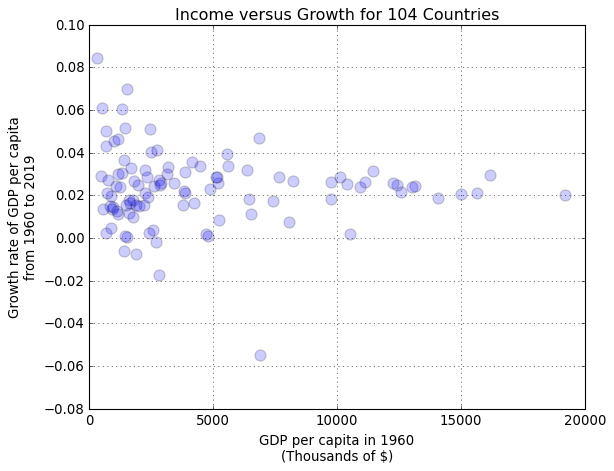

In [25]:
# Use the sort_index() method of data_initial to alphabetize the index [e.g., data_initial = data_initial.sort_index()]
# BEGIN SOLUTION
data_initial = data_initial.sort_index()
# END SOLUTION

# Use the sort_index() method of growth_rates to alphabetize the index
# BEGIN SOLUTION
growth_rates = growth_rates.sort_index()
# END SOLUTION

# Construct a scatter plot with:
#     1. GDP per capita in the initial year on the horizontal axis
#     2. Average growth rate of GDP per capita on the vertical axis
#     3. Size of scatter plot markers at least 50
#     4. Opacity of scatter plot markers no greater than 0.5
#     5. x-axis limit: [0,20000]
#     6. Suitable title and labels for the axes
# BEGIN SOLUTION
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.scatter(data_initial,growth_rates,s=100,alpha=0.2)
ax.set_title('Income versus Growth for '+str(len(data.columns))+' Countries')
ax.set_xlabel('GDP per capita in '+str(data.index[0].year)+'\n(Thousands of $)')
ax.set_ylabel('Growth rate of GDP per capita\nfrom '+str(data.index[0].year)+' to '+str(data.index[-1].year))
ax.set_xlim([0,20000])
ax.grid()
# END SOLUTION

<!-- BEGIN QUESTION -->

### Part (c)

**Question**

1. Describe in words the relationship between GDP per capita in the initial year and average growth of GDP per capita. How is the relationship different for low income countries and high income countries?

_Type your answer here, replacing this text._

**Answer**

1. There is a right-pointing triangle-shaped relationship between GDP per capita in the initial year and average growth of GDP per capita. Countries with high GDP per capita in the initial year had average growth rates that were almost uniformly close to the world average of about 2 percent. Countries with lower GDP per capita in the initial year had much more variation across the average growth rates of their GDP per capita. The countries with the highest growth rates of GDP per capita were among the lowest income initially and the countries with the lowest growth rates of GDP per capita were also among the lowest income initially.<!-- answer -->

<!-- END QUESTION -->

### Part (d)

In this part you will use OLS to estimate the relationship between GDP per capita in the initial year and average growth of GDP per capita.

\begin{align}
g_i & = \beta_0 + \beta_{\text{1}}y_i + \epsilon_i,
\end{align}

where $g_i$ is the average annual growth rate of country $i$, $y_i$ is country $i$'s initial GDP per capita, and $\epsilon_i$ is the residual of the regression.

In [29]:
# Create a variable called `y` that is equal to the average growth rates of the countries
# BEGIN SOLUTION
y = growth_rates
# END SOLUTION

# Create a variable called `x` that is equal to the GDP per capita of the countries in the initial year
# BEGIN SOLUTION
x = data_initial
# END SOLUTION

# Use the Statsmodels function `add_constant()` to add a constant column to the variable `x`
# BEGIN SOLUTION
x = sm.add_constant(data_initial)
# END SOLUTION

# Create a variable called `model_world` equal to the output of the Statsmodels OLS function regressing `y` upon `x`
# BEGIN SOLUTION
model_world = sm.OLS(y,x)
# END SOLUTION

# Create a variable called `results_world` that stores the fitted model (i.e., the output of the `fit()` method of model)
# BEGIN SOLUTION
results_world = model_world.fit()
# END SOLUTION

# Print the summary of results_world generated by the `summary()` method of `results_world`
# BEGIN SOLUTION
print(results_world.summary())
# END SOLUTION

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.6262
Date:                Sun, 13 Oct 2024   Prob (F-statistic):              0.431
Time:                        11:46:17   Log-Likelihood:                 273.81
No. Observations:                 104   AIC:                            -543.6
Df Residuals:                     102   BIC:                            -538.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0244    

<!-- BEGIN QUESTION -->

### Part (e) 

**Questions**

1. Interpret the estimate for the coefficient on $y_i$.
2. Interpret the estimate for the constant. Where did we see this number earlier?
3. Interpret the R-squared of the regression.

_Type your answer here, replacing this text._

**Answers**

1. The estimated coefficient on $y_i$ is both very close to zero and is not statistically different from zero.<!-- answer -->
2. The estimated constant is equal to the average growth rate of GDP per capita across all countries and we computed that in the second code cell of Part (b).<!-- answer -->
3. The R-squared implies that the linear regression model explains essentially zero percent of the variation in average GDP per capita growth across countries.<!-- answer -->

<!-- END QUESTION -->

## Exercise: Income and Growth Across US States

The data file `state_income_data.csv` contains annual data on income per capita for the 48 continental states, Washington D.C., and the United States as a whole and is available here: https://raw.githubusercontent.com/letsgoexploring/economic-data/master/us-convergence/csv/state_income_data.csv. 

In this exercise, you will:

1. Analyze some basic facts about income per capita among US states.
2. Compute the average annual growth rate of income per capita for each state in the data.
3. Compute a linear regression of average income per capita growth on income per capita in the initial year.

Follow the instructions in the following cells.

### Part (a)

In [32]:
# Create a variable called `state_df` that stores the data in the file 'cross_country_gdp_pc.csv' in a DataFrame
# Make sure that 'Year', the left-most column of the data, is set to be the index column
# BEGIN SOLUTION
state_df= pd.read_csv('https://raw.githubusercontent.com/letsgoexploring/economic-data/master/us-convergence/csv/state_income_data.csv',index_col=0,parse_dates=True)
# END SOLUTION

# Display the first 5 rows of `state_df
# BEGIN SOLUTION
display(state_df.head())
# END SOLUTION

,AL,AR,AZ,CA,CO,CT,DC,DE,FL,GA,...,TN,TX,UT,United States,VA,VT,WA,WI,WV,WY
1840-01-01,1032.467532,1324.675325,NaN,NaN,NaN,1772.727273,NaN,1324.675325,1344.155844,1110.389610,...,915.584416,NaN,NaN,1266.233766,1051.948052,1266.233766,NaN,1558.441558,1051.948052,NaN
1880-01-01,1212.121212,1341.991342,5129.870130,4199.134199,4783.549784,3160.173160,NaN,2337.662338,1038.961039,1212.121212,...,1125.541126,1298.701299,1753.246753,2056.277056,1103.896104,2251.082251,3030.303030,2034.632035,1168.831169,3333.333333
1900-01-01,1449.350649,1472.727273,4675.324675,4231.168831,4090.909091,3646.753247,NaN,2922.077922,1566.233766,1309.090909,...,1425.974026,1963.636364,2664.935065,2641.558442,1542.857143,2758.441558,4231.168831,2501.298701,1846.753247,5540.259740
1929-01-01,3634.085213,3451.811347,6812.485760,11323.763955,7188.425609,11722.488038,15083.162452,11745.272272,5912.508544,3907.496013,...,4249.259512,5399.863295,6242.879927,7963.089542,4955.570745,7177.033493,8430.166325,7632.718159,5228.981545,7655.502392
1930-01-01,3109.849829,2648.693390,6125.103465,10512.001892,6787.276812,10961.333806,15537.424619,10145.441646,5533.877261,3582.830791,...,3795.672224,4812.581294,5841.314887,7343.029443,4576.090812,6763.627764,7768.712309,6917.346577,4812.581294,6881.873005


The DataFrame method `dropna()` returns a DataFrame that omits rows that contain missing (NaN means *not a number*) values. The following command will remove the rows with missing values from the DataFrame `df`:

    df =  df.dropna()
    
The DataFrame method `drop()` returns a DataFrame that omits rows or columns with a given label. The following command will remove the column named `'LABEL'` from the DataFrame `df`:   
   
    df = df.drop('LABEL',axis=1)
    
The argument `axis=1` means to look among the columns for `'LABEL'`. If we had wanted to remove a row with the index value `'LABEL'`, then the axis argument would have been: `axis=0`.

In [33]:
# Remove the rows with missing data from `state_df`
# BEGIN SOLUTION
state_df = state_df.dropna()
# END SOLUTION

# Remove the column named 'United States' from `state_df`
# BEGIN SOLUTION
state_df = state_df.drop('United States',axis=1)
# END SOLUTION

# Set `state_df` equal to itself divided by 1000 so that its units are in thousands of dollars
# BEGIN SOLUTION
state_df = state_df/1000
# END SOLUTION

# Display the first 5 rows of `state_df`
# BEGIN SOLUTION
display(state_df.head())
# END SOLUTION

,AL,AR,AZ,CA,CO,CT,DC,DE,FL,GA,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
1929-01-01,3.634085,3.451811,6.812486,11.323764,7.188426,11.722488,15.083162,11.745272,5.912509,3.907496,...,4.727728,4.249260,5.399863,6.242880,4.955571,7.177033,8.430166,7.632718,5.228982,7.655502
1930-01-01,3.109850,2.648693,6.125103,10.512002,6.787277,10.961334,15.537425,10.145442,5.533877,3.582831,...,4.221355,3.795672,4.812581,5.841315,4.576091,6.763628,7.768712,6.917347,4.812581,6.881873
1931-01-01,2.899697,2.728351,5.667589,9.924871,6.221168,10.636615,16.515092,10.228022,5.232635,3.347832,...,3.189667,3.598260,4.547252,4.903124,4.889943,6.207987,7.038355,6.181626,4.665876,6.287070
1932-01-01,2.373134,2.268657,4.805970,8.716418,5.328358,9.358209,16.522388,8.820896,4.731343,2.940299,...,2.820896,2.895522,3.910448,4.537313,4.268657,5.417910,6.000000,5.402985,3.835821,5.597015
1933-01-01,2.517654,2.348787,4.743629,8.443353,5.419097,9.072766,14.507215,8.688978,4.436598,3.101013,...,2.087811,3.085662,3.899294,4.559411,4.390543,5.173473,5.772183,5.127418,3.976052,5.710777


In [34]:
# Create a variable called `state_growth_rates` that contains the average growth rate of each state in the data.
# BEGIN SOLUTION
T = len(state_df)-1
state_growth_rates = (state_df.iloc[-1]/state_df.iloc[0])**(1/T)-1
# END SOLUTION

# Print the value of the variable `state_growth_rates`
# BEGIN SOLUTION
state_growth_rates
# END SOLUTION

AL    0.026968
AR    0.028200
AZ    0.021679
CA    0.019004
CO    0.023782
CT    0.019730
DC    0.018861
DE    0.016495
FL    0.024243
GA    0.027263
IA    0.022222
ID    0.023083
IL    0.018210
IN    0.021324
KS    0.023679
KY    0.025060
LA    0.025151
MA    0.021131
MD    0.020892
ME    0.022079
MI    0.018384
MN    0.023367
MO    0.021314
MS    0.027551
MT    0.022205
NC    0.028137
ND    0.028251
NE    0.023369
NH    0.022686
NJ    0.019944
NM    0.024589
NV    0.018184
NY    0.017510
OH    0.018723
OK    0.024444
OR    0.021391
PA    0.019907
RI    0.018312
SC    0.029527
SD    0.027265
TN    0.026767
TX    0.024835
UT    0.022908
VA    0.026956
VT    0.021849
WA    0.022164
WI    0.020858
WV    0.022719
WY    0.023364
dtype: float64

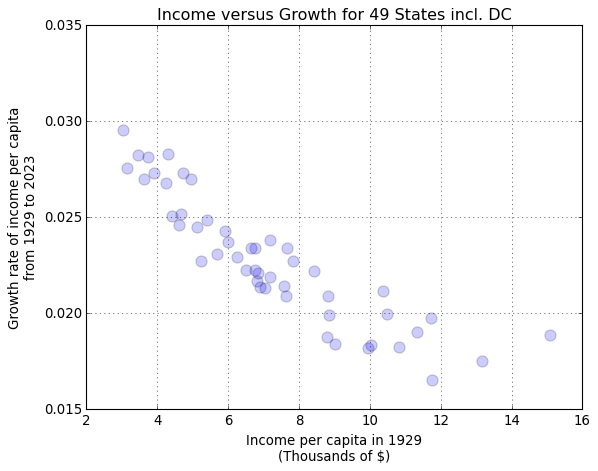

In [35]:
# Construct a scatter plot with:
#     1. Income per capita in the initial year on the horizontal axis
#     2. Average growth rate of income per capita on the vertical axis
#     3. Size of scatter plot markers at least 50
#     4. Opacity of scatter plot markers no greater than 0.5
#     5. y-axis limit: [0.015,0.035]
#     6. Suitable title and labels for the axes
# BEGIN SOLUTION
fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.scatter(state_df.iloc[0],state_growth_rates,s=100,alpha=0.2)
ax.set_title('Income versus Growth for '+str(len(state_df.columns))+' States incl. DC')
ax.set_xlabel('Income per capita in '+str(state_df.index[0].year)+'\n(Thousands of $)')
ax.set_ylabel('Growth rate of income per capita\nfrom '+str(state_df.index[0].year)+' to '+str(state_df.index[-1].year))
ax.set_ylim([0.015,0.035])
ax.grid()
# END SOLUTION

<!-- BEGIN QUESTION -->

### Part (b)

Like you did for the country data above, use OLS to estimate the relationship between income per capita in the initial year and average growth of income per capita.

\begin{align}
g_i & = \beta_0 + \beta_{\text{1}}y_i + \epsilon_i,
\end{align}

where $g_i$ is the average annual growth rate of country $i$, $y_i$ is state $i$'s initial income per capita, and $\epsilon_i$ is the residual of the regression.

In [37]:
# Create a variable called `y_us` that is equal to the average growth rates of the states
# BEGIN SOLUTION
y_us = state_growth_rates
# END SOLUTION

# Create a variable called `x_us` that is equal to the income per capita of the states in the initial year
# BEGIN SOLUTION
x_us = state_df.iloc[0]
# END SOLUTION

# Use the Statsmodels function add_constant() to add a constant column to the variable `x_us`
# BEGIN SOLUTION
x_us = sm.add_constant(x_us)
# END SOLUTION

# Create a variable called `model_us` equal to the output of the Statsmodels OLS function regressing `y` upon `x`
# BEGIN SOLUTION
model_us = sm.OLS(y_us,x_us)
# END SOLUTION

# Create a variable called `results_us` that stores the fitted model (i.e., the output of the `fit()` method of `model_us`)
# BEGIN SOLUTION
results_us = model_us.fit()
# END SOLUTION

# Print the summary of results generated by the `summary()` method of `results_us`
# BEGIN SOLUTION
print(results_us.summary())
# END SOLUTION

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.799
Method:                 Least Squares   F-statistic:                     192.0
Date:                Sun, 13 Oct 2024   Prob (F-statistic):           3.26e-18
Time:                        11:46:18   Log-Likelihood:                 251.23
No. Observations:                  49   AIC:                            -498.5
Df Residuals:                      47   BIC:                            -494.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.0303    

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Part (c) 

**Questions**

1. Interpret the estimate for the coefficient on $y_i$.
2. Interpret the R-squared of the regression.
3. Why do you think that initial income and average growth are so strongly correlated in the state data but not so in the country data? (If you're not sure, referesh your knowledge about the difference between *conditional* and *unconditional* convergence: https://en.wikipedia.org/wiki/Convergence_(economics)#Types_of_Convergence)

_Type your answer here, replacing this text._

**Answers**

1. The estimated coefficient on $y_i$ implies that a \$1,000 increase in income per captia reduces a states average growth rate of income per capita by 1.1 percent. I.e., states with lower initial income had greater income growth than higher income states. <!-- answer -->
2. The R-squared implies that the linear regression model explains about 80 percent of the variation in average income per capita growth across states.<!-- answer -->
3. Lower-income US states are "economically similar" to higher-income states in that they have the same currency, federal regulation, legal traditions, and language, and they have similar laws, poltical institutions. Therefore, it's not surprising to observe *catch-up growth* among the lower-income states. By contrast, lower-income countries are a diverse group with broad differences in policies and institutions and so it is not at all guaranteed that low income countries will enjoy catch-up growth simply by virtue of their low income. <!-- answer -->

<!-- END QUESTION -->

